<a href="https://colab.research.google.com/github/imazzala/coder-house-dsII/blob/main/Proyecto_Final_Mazzalay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final — Data Science II (Coder House)
## Predicción de diabetes a partir de datos clínicos

| Campo | Detalle |
|---|---|
| **Autor** | _Completar con tu nombre_ |
| **Tipo de problema** | Clasificación binaria |
| **Variable objetivo** | `diabetes` |
| **Métrica principal** | Recall (minimizar falsos negativos) |
| **Métrica secundaria** | ROC-AUC |
| **Dataset** | Diabetes Prediction Dataset ([Kaggle](https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset)) |
| **Fuente de los datos** | [CSV en GitHub](https://raw.githubusercontent.com/imazzala/coder-house-dsII/refs/heads/main/diabetes_prediction_dataset.csv) |
| **Entorno de ejecución** | Google Colab o Jupyter Notebook |

**Resumen ejecutivo.** El proyecto desarrolla un pipeline completo de Machine Learning para predecir si una persona presenta diabetes a partir de variables clínicas y demográficas (edad, género, hipertensión, enfermedad cardíaca, hábito de fumar, IMC, nivel de HbA1c y glucosa en sangre). La entrega integra formulación del problema, análisis exploratorio de datos, ingeniería de atributos, entrenamiento de modelos, optimización de hiperparámetros orientada a **recall**, evaluación final y explicabilidad mediante SHAP.


## 1. Formulación del problema

El objetivo del proyecto es construir un modelo supervisado capaz de predecir si una persona tiene diabetes a partir de un conjunto de variables clínicas y demográficas. Se trata de una tarea de **clasificación binaria**, ya que la variable objetivo admite dos clases posibles: sin diabetes y con diabetes. La variable objetivo es `diabetes`, codificada como 1 para los casos positivos y 0 para los casos negativos.

### Métrica de éxito

La métrica principal seleccionada es **recall** (sensibilidad), porque en un escenario de apoyo al diagnóstico clínico, los **falsos negativos** son el error más costoso: un paciente diabético clasificado como sano puede no recibir tratamiento ni seguimiento a tiempo. Por ese motivo, el proceso de optimización de hiperparámetros se enfoca explícitamente en **maximizar el recall**, entendiendo que esto implica aceptar una menor precisión (más falsos positivos) a cambio de detectar la mayor cantidad posible de casos reales de diabetes. Como métrica secundaria se reporta **ROC-AUC**, que permite evaluar la capacidad global del modelo para discriminar entre clases en distintos umbrales, junto con precision y F1-score para tener una visión completa del compromiso entre errores.


## 2. Carga y descripción de los datos

Se utiliza el dataset **Diabetes Prediction Dataset**, descargado directamente desde un repositorio público de GitHub en formato CSV. Esta decisión permite que el proyecto sea reproducible sin depender de descargas manuales desde Kaggle ni de rutas locales.


In [33]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import os
os.makedirs("outputs/graficos", exist_ok=True)

In [34]:
url = "https://raw.githubusercontent.com/imazzala/coder-house-dsII/refs/heads/main/diabetes_prediction_dataset.csv"
df = pd.read_csv(url)
print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


De los resultados se observa que el dataset consta de 100.000 registros y 9 columnas. No posee valores registros nulos.

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [36]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,100000.0,41.885856,22.516840,0.08,24.00,43.00,60.00,80.00
hypertension,100000.0,0.074850,0.263150,0.00,0.00,0.00,0.00,1.00
heart_disease,100000.0,0.039420,0.194593,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,5.527507,1.070672,3.50,4.80,5.80,6.20,9.00
blood_glucose_level,100000.0,138.058060,40.708136,80.00,100.00,140.00,159.00,300.00
diabetes,100000.0,0.085000,0.278883,0.00,0.00,0.00,0.00,1.00


### Calidad de los datos

Se revisan valores faltantes, filas duplicadas y categorías poco representadas antes de continuar con el análisis.


In [37]:
missing_values = df.isnull().sum().sort_values(ascending=False)
print("Valores faltantes por columna:")
print(missing_values)
print("\nTotal de valores faltantes:", missing_values.sum())

Valores faltantes por columna:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Total de valores faltantes: 0


Se identifican los valores duplicados y se decide eliminarlos.

In [38]:
n_duplicados = df.duplicated().sum()
print("Filas duplicadas detectadas:", n_duplicados)

df = df.drop_duplicates().reset_index(drop=True)
print("Dimensiones luego de eliminar duplicados:", df.shape)

Filas duplicadas detectadas: 3854
Dimensiones luego de eliminar duplicados: (96146, 9)


In [39]:
print("Categorías de género:")
print(df["gender"].value_counts())

# La categoría 'Other' está muy poco representada (< 0.02% del dataset)
# y no aporta señal suficiente para el modelo, por lo que se descarta.
other_count = (df["gender"] == "Other").sum()
df = df[df["gender"] != "Other"].reset_index(drop=True)
print(f"\nFilas con género 'Other' eliminadas: {other_count}")
print("Dimensiones finales del dataset:", df.shape)

Categorías de género:
gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64

Filas con género 'Other' eliminadas: 18
Dimensiones finales del dataset: (96128, 9)


Se observa que el dataset está desbalanceado. Se obtiene un 91.18% de casos negativos contra un 8.82% de casos positivos.

In [40]:
target_counts = df["diabetes"].value_counts().sort_index()
target_props = (df["diabetes"].value_counts(normalize=True).sort_index() * 100).round(2)
pd.DataFrame({
    "conteo": target_counts,
    "proporcion_%": target_props
}).rename(index={0: "sin diabetes", 1: "con diabetes"})

,conteo,proporcion_%
diabetes,,
sin diabetes,87646,91.18
con diabetes,8482,8.82


**Resumen de la carga y limpieza de datos:**

| Característica | Resultado |
|---|---|
| Observaciones originales | 100.000 |
| Duplicados eliminados | 3.854 |
| Filas con género 'Other' eliminadas | 18 |
| Observaciones finales | 96.128 |
| Variables predictoras originales | 8 |
| Variable objetivo | `diabetes` |
| Casos sin diabetes | 87.646 (91,18 %) |
| Casos con diabetes | 8.482 (8,82 %) |
| Valores faltantes | 0 |

El dataset presenta un **fuerte desbalance de clases** (aprox. 91 % / 9 %), lo cual es consistente con la prevalencia real de la diabetes en la población general y refuerza la necesidad de optimizar el modelo por recall y no únicamente por accuracy.


## 3. Análisis Exploratorio de Datos (EDA)

El análisis exploratorio permite revisar la estructura del dataset, entender la distribución de las variables numéricas, comparar su comportamiento según el diagnóstico y analizar la relación entre las variables predictoras y la variable objetivo.


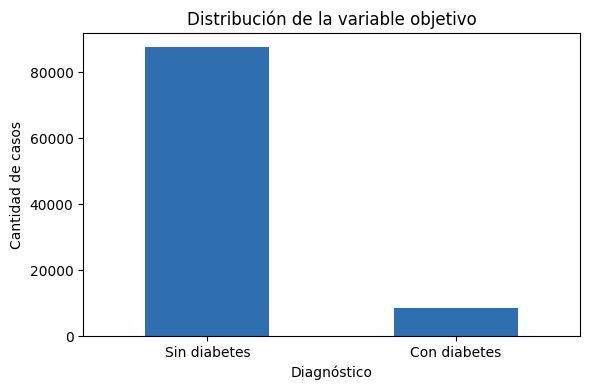

In [41]:
plt.figure(figsize=(6, 4))
df["diabetes"].map({0: "Sin diabetes", 1: "Con diabetes"}).value_counts().plot(kind="bar", color="#2f6fb0")
plt.title("Distribución de la variable objetivo")
plt.xlabel("Diagnóstico")
plt.ylabel("Cantidad de casos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs/graficos/distribucion_target.png", dpi=150)
plt.show()

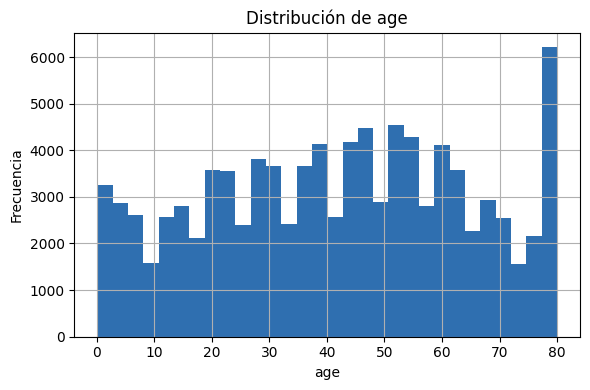

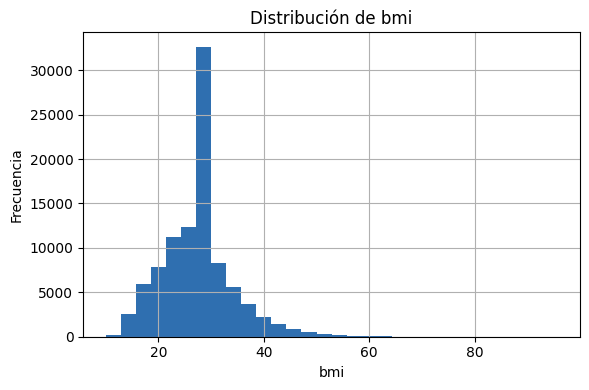

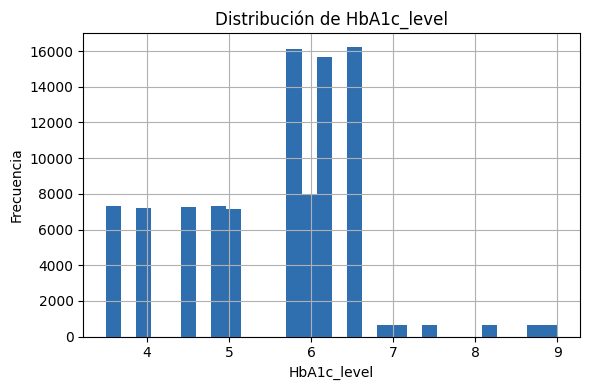

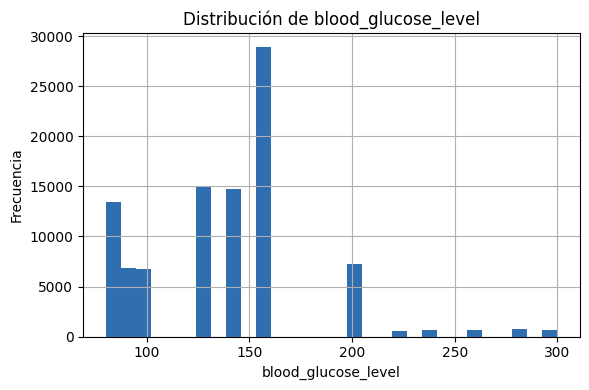

In [42]:
numeric_selected = ["age", "bmi", "HbA1c_level", "blood_glucose_level"]

for feature in numeric_selected:
    plt.figure(figsize=(6, 4))
    df[feature].hist(bins=30, color="#2f6fb0")
    plt.title(f"Distribución de {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.savefig(f"outputs/graficos/hist_{feature}.png", dpi=150)
    plt.show()

<Figure size 600x400 with 0 Axes>

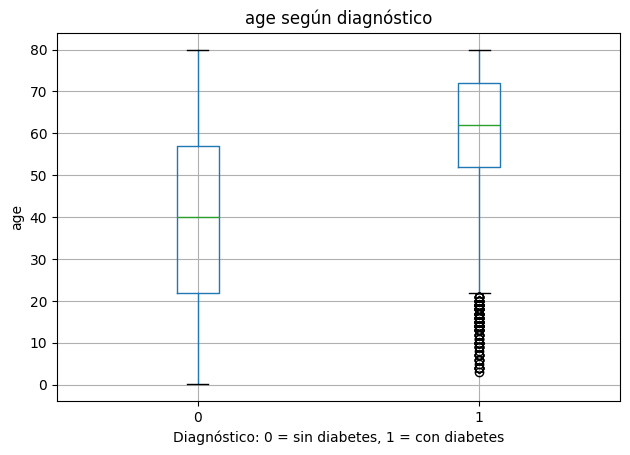

<Figure size 600x400 with 0 Axes>

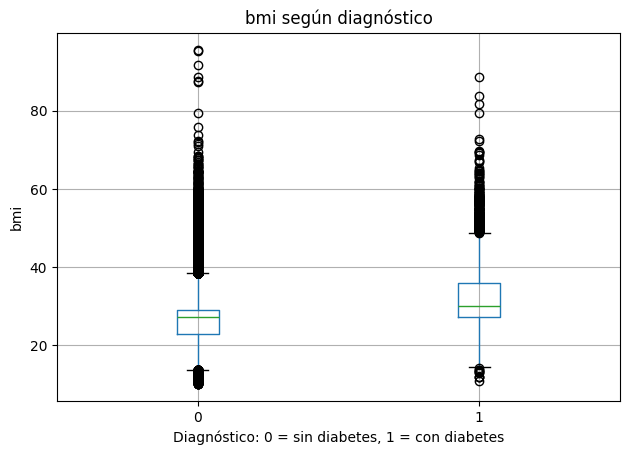

<Figure size 600x400 with 0 Axes>

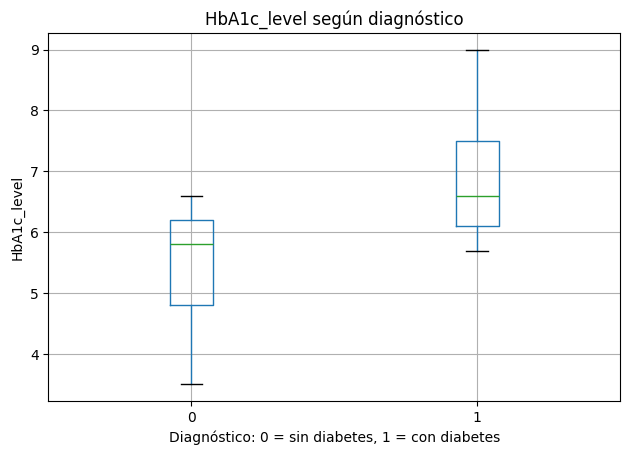

<Figure size 600x400 with 0 Axes>

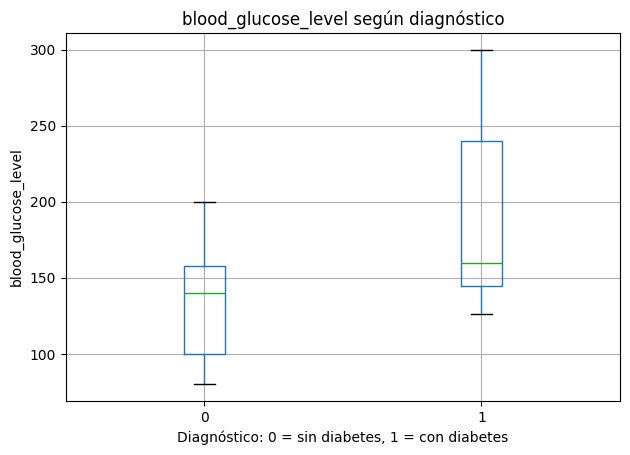

In [43]:
for feature in numeric_selected:
    plt.figure(figsize=(6, 4))
    df.boxplot(column=feature, by="diabetes")
    plt.title(f"{feature} según diagnóstico")
    plt.suptitle("")
    plt.xlabel("Diagnóstico: 0 = sin diabetes, 1 = con diabetes")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.savefig(f"outputs/graficos/boxplot_{feature}.png", dpi=150)
    plt.show()

In [44]:
corr_cols = ["age", "hypertension", "heart_disease", "bmi", "HbA1c_level", "blood_glucose_level", "diabetes"]
corr_target = df[corr_cols].corr(numeric_only=True)["diabetes"].drop("diabetes").sort_values(key=abs, ascending=False)
corr_target

,diabetes
blood_glucose_level,0.424366
HbA1c_level,0.406446
age,0.264918
bmi,0.214951
hypertension,0.195696
heart_disease,0.170701


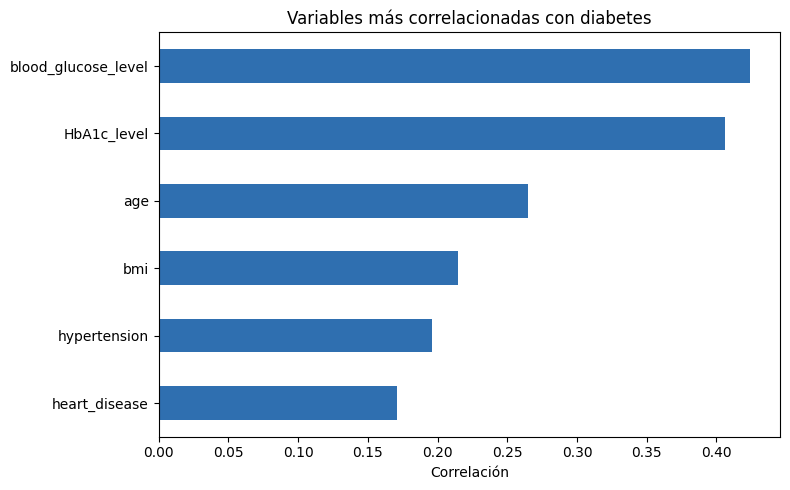

In [45]:
plt.figure(figsize=(8, 5))
corr_target.sort_values().plot(kind="barh", color="#2f6fb0")
plt.title("Variables más correlacionadas con diabetes")
plt.xlabel("Correlación")
plt.tight_layout()
plt.savefig("outputs/graficos/correlaciones_target.png", dpi=150)
plt.show()

In [46]:
print("Tasa de diabetes por smoking_history:")
print((df.groupby("smoking_history")["diabetes"].mean() * 100).round(2).sort_values(ascending=False))

print("\nTasa de diabetes por hipertensión:")
print((df.groupby("hypertension")["diabetes"].mean() * 100).round(2))

print("\nTasa de diabetes por enfermedad cardíaca:")
print((df.groupby("heart_disease")["diabetes"].mean() * 100).round(2))

Tasa de diabetes por smoking_history:
smoking_history
former         17.10
ever           11.81
not current    10.85
current        10.31
never           9.70
No Info         4.39
Name: diabetes, dtype: float64

Tasa de diabetes por hipertensión:
hypertension
0     7.21
1    27.96
Name: diabetes, dtype: float64

Tasa de diabetes por enfermedad cardíaca:
heart_disease
0     7.82
1    32.30
Name: diabetes, dtype: float64


**Insights del EDA:**

- La variable objetivo está **fuertemente desbalanceada**: solo el 8,82 % de las observaciones corresponde a casos con diabetes. Esto justifica priorizar recall y reportar métricas adicionales al accuracy.
- `blood_glucose_level` y `HbA1c_level` son, por amplio margen, las variables individuales más correlacionadas con el diagnóstico, lo cual es clínicamente coherente ya que ambas son indicadores directos del control glucémico.
- `age` y `bmi` también muestran una relación moderada con la variable objetivo.
- Las personas con **hipertensión** presentan una tasa de diabetes de 27,96 % frente a 7,21 % en quienes no la tienen. Un patrón similar, aún más marcado, se observa con **enfermedad cardíaca** (32,30 % vs. 7,82 %).
- La categoría `former` (ex fumador) de `smoking_history` presenta la mayor tasa de diabetes (17,10 %), posiblemente asociada a una edad promedio mayor en ese grupo.

Esta evidencia sugiere que los modelos deberían poder capturar una señal predictiva significativa, especialmente a partir de las variables glucémicas y las comorbilidades cardiovasculares.


## 4. Ingeniería de atributos

El dataset original contiene variables numéricas limpias, pero se agregan variables derivadas para reforzar la señal disponible, combinando indicadores glucémicos, antropométricos y de comorbilidad.

| Variable creada | Justificación |
|---|---|
| `glucose_hba1c_interaction` | Combina el nivel de glucosa en sangre y la hemoglobina glicosilada, las dos variables individuales más correlacionadas con el diagnóstico, para capturar el efecto conjunto del control glucémico. |
| `bmi_age_interaction` | Relaciona el índice de masa corporal con la edad, capturando el riesgo metabólico acumulado. |
| `comorbidity_score` | Suma de hipertensión y enfermedad cardíaca; resume la carga de comorbilidades cardiovasculares del paciente. |
| `glucose_bmi_ratio` | Relaciona el nivel de glucosa con el IMC, para representar el nivel glucémico en proporción a la masa corporal. |

Además, se utiliza un pipeline de preprocesamiento con imputación por mediana (variables numéricas) / moda (variables categóricas), estandarización de variables numéricas y codificación one-hot de las variables categóricas (`gender`, `smoking_history`). La imputación aumenta la robustez del flujo de trabajo ante datos futuros con nulos, y la estandarización permite que los modelos sensibles a la escala, como la regresión logística, trabajen con variables comparables.


In [47]:
df["glucose_hba1c_interaction"] = df["blood_glucose_level"] * df["HbA1c_level"]
df["bmi_age_interaction"] = df["bmi"] * df["age"]
df["comorbidity_score"] = df["hypertension"] + df["heart_disease"]
df["glucose_bmi_ratio"] = df["blood_glucose_level"] / df["bmi"]

new_features = ["glucose_hba1c_interaction", "bmi_age_interaction", "comorbidity_score", "glucose_bmi_ratio"]
df[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
glucose_hba1c_interaction,96128.0,772.248899,312.609890,280.00000,549.000000,754.000000,928.000000,2700.000000
bmi_age_interaction,96128.0,1194.359586,714.748814,0.88400,616.460000,1199.680000,1721.160000,7100.800000
comorbidity_score,96128.0,0.118425,0.351339,0.00000,0.000000,0.000000,0.000000,2.000000
glucose_bmi_ratio,96128.0,5.336933,1.987675,0.94518,3.814974,5.124451,6.273526,25.500911


## 5. Separación de datos y pipeline de preprocesamiento

Se separa el dataset en conjuntos de entrenamiento (80 %) y test (20 %), utilizando muestreo estratificado para preservar la proporción de clases en ambos conjuntos. Sobre esa base se define un `ColumnTransformer` que aplica el preprocesamiento adecuado a cada tipo de variable.


In [48]:
X = df.drop(columns=["diabetes"])
y = df["diabetes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño test:", X_test.shape)
print("Proporción de positivos en train:", round(y_train.mean(), 4))
print("Proporción de positivos en test:", round(y_test.mean(), 4))

Tamaño entrenamiento: (76902, 12)
Tamaño test: (19226, 12)
Proporción de positivos en train: 0.0882
Proporción de positivos en test: 0.0882


In [49]:
numeric_features = [
    "age", "hypertension", "heart_disease", "bmi", "HbA1c_level",
    "blood_glucose_level", "glucose_hba1c_interaction",
    "bmi_age_interaction", "comorbidity_score", "glucose_bmi_ratio"
]
categorical_features = ["gender", "smoking_history"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## 6. Entrenamiento de modelos base

Se entrenaron tres modelos supervisados para comparar enfoques con distintos niveles de complejidad: **regresión logística**, **Random Forest** y **XGBoost**. La regresión logística funciona como modelo lineal base e interpretable; Random Forest permite capturar relaciones no lineales mediante ensambles de árboles; XGBoost aporta un esquema de boosting eficiente y competitivo para problemas tabulares.

Dado el fuerte desbalance de clases, la regresión logística y Random Forest se entrenan con `class_weight="balanced"`, mientras que XGBoost utiliza el parámetro `scale_pos_weight`, calculado como la razón entre observaciones negativas y positivas del conjunto de entrenamiento.


In [50]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight utilizado en XGBoost:", round(scale_pos_weight, 2))

models = {
    "Regresión logística": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(
            n_estimators=100,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=1
        ))
    ]),
    "XGBoost": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", XGBClassifier(
            n_estimators=100,
            max_depth=4,
            learning_rate=0.1,
            subsample=0.9,
            colsample_bytree=0.9,
            scale_pos_weight=scale_pos_weight,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=1,
            verbosity=0
        ))
    ])
}

scale_pos_weight utilizado en XGBoost: 10.33


In [51]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"auc": "roc_auc", "f1": "f1", "recall": "recall", "precision": "precision"}

cv_results = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    cv_results.append({
        "modelo": name,
        "AUC_CV_media": scores["test_auc"].mean(),
        "Recall_CV_media": scores["test_recall"].mean(),
        "Precision_CV_media": scores["test_precision"].mean(),
        "F1_CV_media": scores["test_f1"].mean(),
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("Recall_CV_media", ascending=False)
cv_results_df.round(4)

,modelo,AUC_CV_media,Recall_CV_media,Precision_CV_media,F1_CV_media
2,XGBoost,0.9795,0.9260,0.4726,0.6258
0,Regresión logística,0.9626,0.8814,0.4351,0.5825
1,Random Forest,0.9669,0.6836,0.9487,0.7945


Los resultados de validación cruzada muestran que **XGBoost con `scale_pos_weight`** obtiene el mejor recall entre los tres modelos, seguido por la regresión logística balanceada. Random Forest, en cambio, prioriza la precisión pero sacrifica recall de forma considerable: al tratarse de un ensamble de árboles con umbral de decisión implícito en 0,5, tiende a ser más conservador para asignar la clase positiva a pesar del `class_weight="balanced"`.

Dado que la métrica principal del proyecto es el recall, **XGBoost es el modelo elegido para continuar con la optimización de hiperparámetros**.


## 7. Optimización de hiperparámetros (GridSearchCV orientado a recall)

Se optimiza XGBoost mediante `GridSearchCV`, buscando la combinación de hiperparámetros que **maximiza el recall** en validación cruzada, ya que el objetivo del proyecto es minimizar los falsos negativos (pacientes con diabetes clasificados como sanos). Como métricas de referencia adicionales se registran también ROC-AUC, precision y F1 para poder contextualizar el compromiso entre errores que implica cada combinación de hiperparámetros.


In [52]:
xgb_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbosity=0
    ))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 4, 5],
    "model__learning_rate": [0.05, 0.1],
}

grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring={"recall": "recall", "auc": "roc_auc", "precision": "precision", "f1": "f1"},
    refit="recall",
    cv=cv,
    n_jobs=1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(grid_search.best_params_)
print("\nMejor Recall promedio en CV:", round(grid_search.best_score_, 4))

Mejores hiperparámetros:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}

Mejor Recall promedio en CV: 0.9276


In [53]:
best_idx = grid_search.best_index_
cvres = grid_search.cv_results_

print("Métricas de CV para la mejor combinación de hiperparámetros:")
print("Recall CV media:   ", round(cvres["mean_test_recall"][best_idx], 4))
print("ROC-AUC CV media:  ", round(cvres["mean_test_auc"][best_idx], 4))
print("Precision CV media:", round(cvres["mean_test_precision"][best_idx], 4))
print("F1 CV media:       ", round(cvres["mean_test_f1"][best_idx], 4))

Métricas de CV para la mejor combinación de hiperparámetros:
Recall CV media:    0.9276
ROC-AUC CV media:   0.9764
Precision CV media: 0.4324
F1 CV media:        0.5898


**Resumen de la optimización:**

| Elemento | Resultado |
|---|---|
| Técnica utilizada | GridSearchCV |
| Métrica de optimización (refit) | Recall |
| Validación cruzada | StratifiedKFold de 5 particiones |
| Mejor `learning_rate` | 0,05 |
| Mejor `max_depth` | 3 |
| Mejor `n_estimators` | 100 |
| Mejor Recall promedio en CV | 0,9276 |
| ROC-AUC promedio en CV (misma combinación) | 0,9764 |

Es esperable que, al optimizar explícitamente por recall, la precisión de la mejor combinación resulte más baja que la de un modelo optimizado por AUC o F1. Este compromiso es intencional y coherente con el objetivo de negocio: se prioriza detectar la mayor cantidad posible de casos reales de diabetes, aun a costa de generar más falsos positivos, que en un contexto clínico implican estudios adicionales, mientras que un falso negativo implica un diagnóstico perdido.


## 8. Evaluación final del modelo seleccionado

El modelo optimizado se evaluó sobre el conjunto de test, separado previamente y no utilizado durante el entrenamiento ni durante la búsqueda de hiperparámetros. Este paso permite estimar el desempeño del modelo ante datos no vistos.


In [54]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

final_metrics = pd.DataFrame([{
    "modelo": "XGBoost optimizado (recall)",
    "ROC_AUC": roc_auc_score(y_test, y_proba),
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred)
}])
final_metrics.round(4)

,modelo,ROC_AUC,Accuracy,Precision,Recall,F1
0,XGBoost optimizado (recall),0.9741,0.8835,0.426,0.9228,0.5829


In [55]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Sin diabetes", "Con diabetes"]
))

              precision    recall  f1-score   support

Sin diabetes       0.99      0.88      0.93     17530
Con diabetes       0.43      0.92      0.58      1696

    accuracy                           0.88     19226
   macro avg       0.71      0.90      0.76     19226
weighted avg       0.94      0.88      0.90     19226



In [56]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[15421,  2109],
       [  131,  1565]])

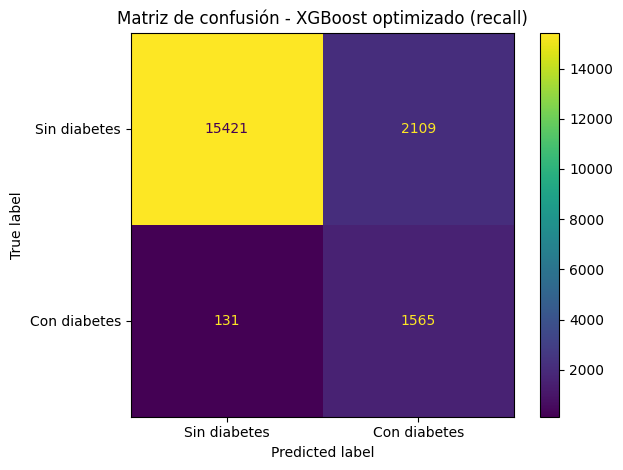

In [57]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Sin diabetes", "Con diabetes"],
    cmap="viridis"
)
plt.title("Matriz de confusión - XGBoost optimizado (recall)")
plt.tight_layout()
plt.savefig("outputs/graficos/matriz_confusion.png", dpi=150)
plt.show()

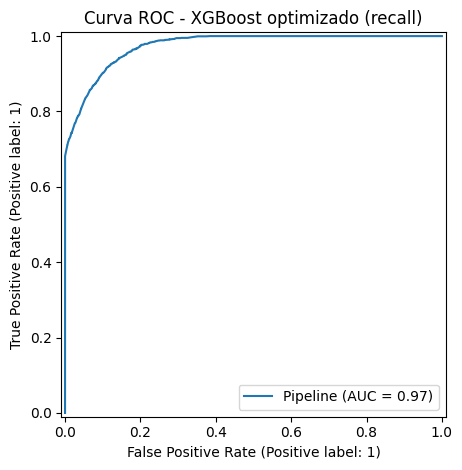

In [58]:
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Curva ROC - XGBoost optimizado (recall)")
plt.tight_layout()
plt.savefig("outputs/graficos/curva_roc.png", dpi=150)
plt.show()

La matriz de confusión muestra **1.565 verdaderos positivos** y **131 falsos negativos**, es decir que el modelo logra identificar correctamente al 92,3 % de las personas con diabetes del conjunto de test. A cambio, se generan 2.109 falsos positivos: personas sin diabetes que el modelo clasifica como positivas. En este problema, los **falsos negativos son el tipo de error más relevante** desde el punto de vista clínico, por lo que este resultado es consistente con el objetivo definido en la formulación del problema. El ROC-AUC de 0,9741 confirma que, más allá del umbral de decisión utilizado, el modelo mantiene una capacidad de discriminación muy alta entre ambas clases.


## 9. Selección del modelo

El modelo seleccionado es **XGBoost optimizado por recall**. La elección se justifica por:

- Su **recall de 0,9228** en test, muy superior al de los modelos base evaluados en la sección 6, lo que se alinea directamente con el objetivo de negocio de minimizar falsos negativos.
- Un **ROC-AUC de 0,9741**, que indica una capacidad de discriminación alta y estable independientemente del umbral elegido.
- Su capacidad para capturar relaciones no lineales entre variables clínicas y su compatibilidad con herramientas de interpretabilidad como SHAP.
- Su eficiencia computacional frente a Random Forest, y su mejor manejo del desbalance de clases mediante `scale_pos_weight` frente a la regresión logística.

Random Forest quedó descartado a pesar de su buena precisión, porque su recall (68,4 % en CV) resulta insuficiente para el objetivo clínico planteado. La regresión logística, si bien es más interpretable de forma nativa, obtiene un recall y un AUC menores que XGBoost.


## 10. Explicabilidad con SHAP

Se utilizó SHAP (SHapley Additive exPlanations) para interpretar la contribución de las variables a las predicciones del modelo final. La explicabilidad es especialmente importante en un contexto clínico, donde un modelo no debería evaluarse únicamente por su desempeño numérico, sino también por la posibilidad de comprender y justificar ante profesionales de la salud qué variables influyen en cada predicción.


In [59]:
trained_preprocess = best_model.named_steps["preprocess"]
trained_xgb = best_model.named_steps["model"]

X_test_processed = trained_preprocess.transform(X_test)
feature_names = trained_preprocess.get_feature_names_out()
feature_names = [name.replace("num__", "").replace("cat__", "") for name in feature_names]

# Se utiliza una muestra del conjunto de test para acelerar el cálculo de SHAP
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(X_test_processed.shape[0], size=2000, replace=False)

X_test_processed_dense = X_test_processed[sample_idx]
if hasattr(X_test_processed_dense, "toarray"):
    X_test_processed_dense = X_test_processed_dense.toarray()

X_sample_df = pd.DataFrame(X_test_processed_dense, columns=feature_names)

explainer = shap.TreeExplainer(trained_xgb)
shap_values = explainer.shap_values(X_sample_df)

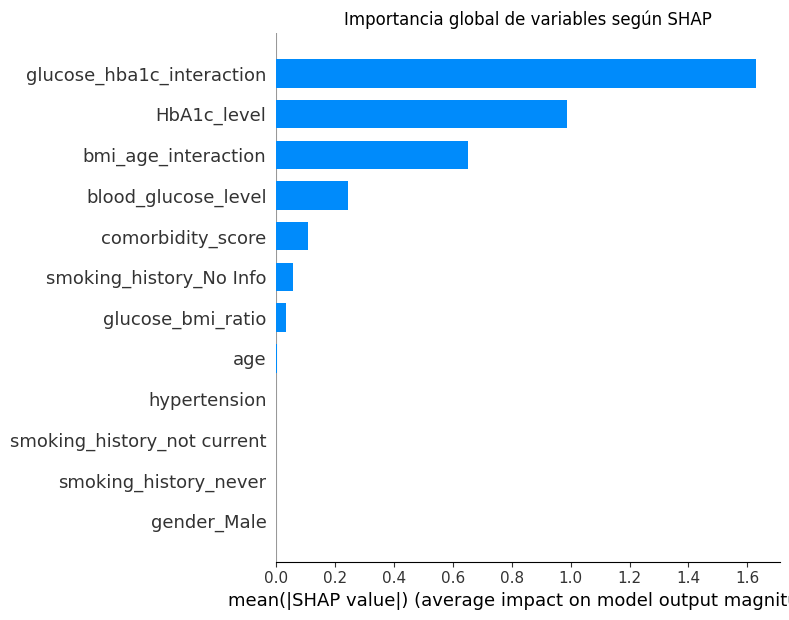

In [60]:
shap.summary_plot(
    shap_values,
    X_sample_df,
    plot_type="bar",
    max_display=12,
    show=False
)
plt.title("Importancia global de variables según SHAP")
plt.tight_layout()
plt.savefig("outputs/graficos/shap_importancia_global.png", dpi=150)
plt.show()

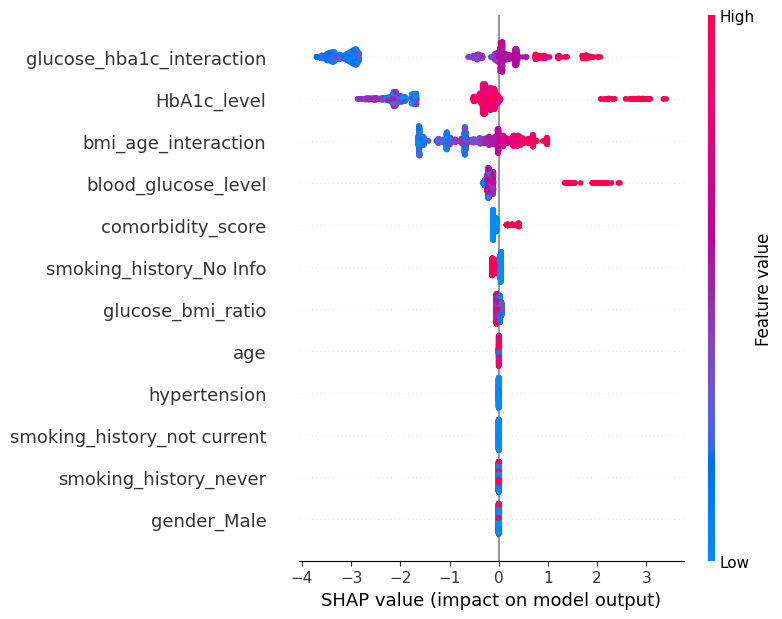

In [61]:
shap.summary_plot(
    shap_values,
    X_sample_df,
    max_display=12,
    show=False
)
plt.tight_layout()
plt.savefig("outputs/graficos/shap_summary.png", dpi=150)
plt.show()

Los gráficos SHAP muestran que las variables con mayor peso en las predicciones son, en orden de importancia: `glucose_hba1c_interaction`, `HbA1c_level`, `bmi_age_interaction` y `blood_glucose_level`. Es decir, tanto las variables originales de control glucémico como las interacciones creadas en la etapa de ingeniería de atributos concentran la mayor parte de la señal predictiva del modelo. Esto es consistente con los patrones observados durante el EDA, donde `blood_glucose_level` y `HbA1c_level` ya se destacaban como las variables individuales más correlacionadas con el diagnóstico, y confirma que las variables derivadas lograron sintetizar de forma efectiva esa información. El `comorbidity_score` también aporta señal relevante, en línea con la mayor tasa de diabetes observada en pacientes con hipertensión y/o enfermedad cardíaca. En conjunto, la explicación permite justificar la selección del modelo no solo por sus métricas, sino también por la coherencia clínica de las variables que más influyen en sus decisiones.


## 12. Conclusiones

El proyecto permitió construir un pipeline completo de Machine Learning para un problema de clasificación binaria orientado a un caso de uso clínico. Se definió una variable objetivo clara (`diabetes`), se seleccionó recall como métrica principal alineada con el objetivo de minimizar falsos negativos, se realizó un análisis exploratorio de datos que evidenció un fuerte desbalance de clases, se crearon variables derivadas a partir de los indicadores glucémicos y de comorbilidad más relevantes, se entrenaron y compararon tres modelos supervisados, se optimizó XGBoost mediante GridSearchCV maximizando recall, y se evaluó el modelo final sobre datos no vistos.

El modelo **XGBoost optimizado** obtuvo un **ROC-AUC de 0,9741** en test, con **accuracy de 0,8835**, **precision de 0,4260**, **recall de 0,9228** y **F1-score de 0,5829**. Estos resultados indican que el modelo logra detectar más del 92 % de los casos reales de diabetes en el conjunto de test, con el costo esperado de una menor precisión producto de haber priorizado explícitamente el recall durante la optimización.

**Mejoras futuras:**
- Ajustar el umbral de decisión (más allá del valor por defecto de 0,5) para explorar de forma más fina el compromiso entre recall y precision según el contexto de uso.
- Validar el modelo con datos clínicos externos, de otra población o institución.
- Incorporar variables clínicas adicionales (por ejemplo, antecedentes familiares o presión arterial) si estuvieran disponibles.
- Probar alternativas para balancear datos como SMOTETomek, creando datos sinteticos y eliminando datos para balancear el dataset.
